# WSX solenoid — 5000-particle Gaussian, G4BL vs OPALX

Same solenoid, same geometry and same frame as `../wsx_solenoid/`; only the beam
differs. 5000 particles from a Gaussian with **σx ≠ σy**, so the Larmor rotation shows
up directly as the x–y ellipse turning as it crosses the field.

Eight recording planes, six of them inside the field, so the rotation can be watched
developing rather than only compared at the ends.

Order of use: run **Setup** and **Write the beam**, run both codes, then the rest.


## Setup


In [47]:
import subprocess, sys
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

from opalxruns.opalx_diagnostics import parse_opal_stat

HERE = Path.cwd()

MU_MASS     = 0.1056583755         # GeV
MU_MASS_MEV = MU_MASS * 1e3        # mass in MeV/c^2; numerically m*c in MeV/c
P0          = 0.028                # GeV/c
BG0         = P0 / MU_MASS
GAMMA0      = np.sqrt(1.0 + BG0**2)
BETA0       = BG0 / GAMMA0
BRHO        = P0 / 0.299792458     # T*m   (0.299792458 = 1e-9*c; charge = 1e)
C_MM_PER_NS = 299.792458           # c, g4bl reports mm and ns

# --- beam --------------------------------------------------------------------
NPART = 15000
SEED  = 20260818
SIG   = dict(x=10e-3, y=3e-3,      # m    -- deliberately different, this is the point
             xp=2e-3, yp=2e-3,     # rad  -- nearly parallel
             z=1e-3)               # m    -- only so the longitudinal stats are defined

# --- the 8 recording planes, identical in both codes -------------------------
PLANES_MM = [150, 600, 1050, 1500, 1950, 2400, 2850, 3450]
OPALX_MON = [f"MON_{i+1:02d}_Z{z}.h5" for i, z in enumerate(PLANES_MM)]
G4BL_NT   = [f"Z{z}.txt" for z in PLANES_MM]
# field spans 300..3300 mm, so planes 1 and 8 are field-free and 2..7 are inside

print(f"beta*gamma {BG0:.7f}   beta {BETA0:.7f}   Brho {BRHO:.6f} T*m")
print(f"beam: {NPART} particles, sigma_x = {SIG['x']*1e3:g} mm, "
      f"sigma_y = {SIG['y']*1e3:g} mm  (aspect {SIG['x']/SIG['y']:.1f}:1)")
print("planes [mm]:", PLANES_MM)


beta*gamma 0.2650050   beta 0.2561628   Brho 0.093398 T*m
beam: 15000 particles, sigma_x = 10 mm, sigma_y = 3 mm  (aspect 3.3:1)
planes [mm]: [150, 600, 1050, 1500, 1950, 2400, 2850, 3450]


## The setup

Where the solenoid sits and where the particles are recorded. Both codes use this
identical geometry; `z` here is g4bl's global z, which equals OPALX path length `s`
times 1000 by construction.


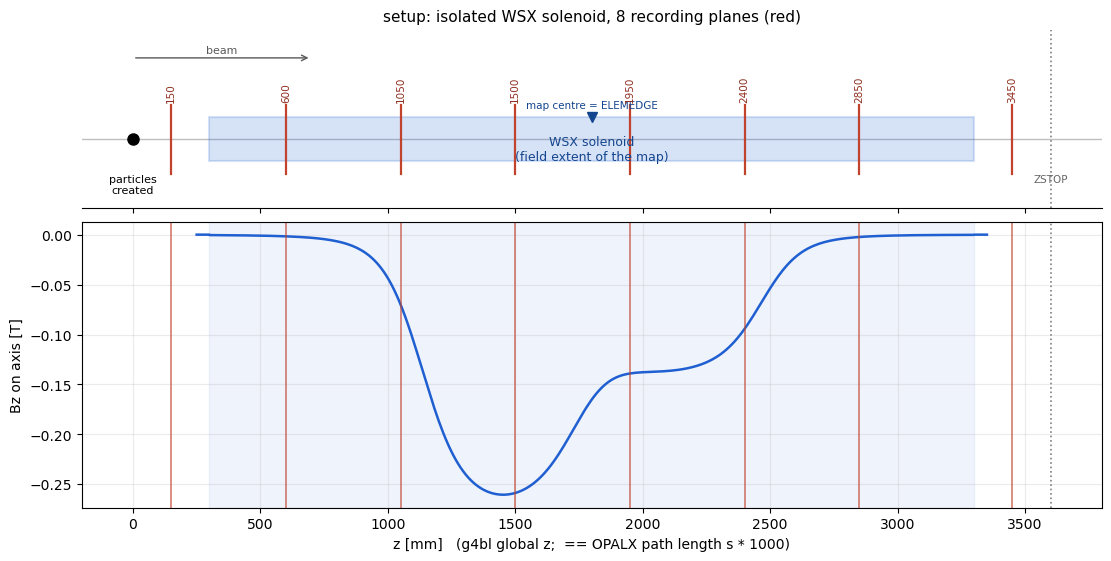

field      300 .. 3300 mm   (map centre 1800 mm)
planes     [150, 600, 1050, 1500, 1950, 2400, 2850, 3450]
planes in field-free drift: [150, 3450]


In [48]:
# --- the setup being tested -------------------------------------------------
# Geometry is fixed by the two input files and is the same in both codes:
#   g4bl  `place MAG z=1800`, map local z -1500..+1500  -> field at 300..3300 mm
#   opalx `SOLENOID ELEMEDGE = 1.800`                   -> field at 0.300..3.300 m
# ELEMEDGE is the lab position of the map CENTRE, not of the field start.
MAP_CENTRE_MM = 1800
FIELD_MM      = (300, 3300)
ZSTOP_MM      = 3600
PLANES = PLANES_MM if "PLANES_MM" in dir() else [Z_IN_MM, Z_OUT_MM]

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                       gridspec_kw=dict(height_ratios=[1, 1.6]),
                       constrained_layout=True)

# ---- schematic ----
a = ax[0]
a.axhline(0, color="0.75", lw=1, zorder=0)
a.add_patch(plt.Rectangle((FIELD_MM[0], -0.35), FIELD_MM[1] - FIELD_MM[0], 0.7,
                          facecolor="#1f5fd1", alpha=0.18, edgecolor="#1f5fd1", lw=1.5))
a.text(np.mean(FIELD_MM), -0.15, "WSX solenoid\n(field extent of the map)",
       ha="center", va="center", fontsize=9, color="#14458f")
a.plot([MAP_CENTRE_MM], [0.35], "v", ms=7, color="#14458f")
a.annotate("map centre = ELEMEDGE", (MAP_CENTRE_MM, 0.50), ha="center", fontsize=7.5,
           color="#14458f")

a.plot([0], [0], "o", ms=8, color="black", zorder=5)
a.annotate("particles\ncreated", (0, -0.55), ha="center", va="top", fontsize=8)
a.annotate("", xy=(700, 1.30), xytext=(0, 1.30),
           arrowprops=dict(arrowstyle="->", color="0.35"))
a.text(350, 1.38, "beam", ha="center", fontsize=8, color="0.35")

for z in PLANES:
    a.plot([z, z], [-0.55, 0.55], "-", color="#c1432d", lw=1.6)
    a.annotate(f"{z}", (z, 0.62), ha="center", fontsize=7.5, rotation=90,
               color="#8f2f1f")
a.axvline(ZSTOP_MM, color="0.5", ls=":", lw=1.2)
a.annotate("ZSTOP", (ZSTOP_MM, -0.55), ha="center", va="top", fontsize=7.5, color="0.4")

a.set_ylim(-1.1, 1.75); a.set_yticks([])
a.set_title(f"setup: isolated WSX solenoid, {len(PLANES)} recording plane"
            f"{'s' if len(PLANES) > 1 else ''} (red)", fontsize=11)
for side in ("left", "right", "top"):
    a.spines[side].set_visible(False)

# ---- on-axis field, if g4bl has already been run ----
b = ax[1]
axis_file = Path("g4bl_axis.txt")
if axis_file.is_file():
    d = np.loadtxt(axis_file, comments="#", ndmin=2)
    b.plot(d[:, 2], d[:, 6], "-", color="#1f5fd1", lw=1.8)
    b.set_ylabel("Bz on axis [T]")
else:
    b.text(0.5, 0.5, "run g4bl to see the on-axis field here",
           transform=b.transAxes, ha="center", va="center", color="0.5", fontsize=9)
    b.set_yticks([])
b.axvspan(*FIELD_MM, color="#1f5fd1", alpha=0.07)
for z in PLANES:
    b.axvline(z, color="#c1432d", lw=1.2, alpha=0.7)
b.axvline(ZSTOP_MM, color="0.5", ls=":", lw=1.2)
b.grid(alpha=0.25)
b.set_xlabel("z [mm]   (g4bl global z;  == OPALX path length s * 1000)")
b.set_xlim(-200, ZSTOP_MM + 200)
plt.show()

print(f"field      {FIELD_MM[0]} .. {FIELD_MM[1]} mm   (map centre {MAP_CENTRE_MM} mm)")
print(f"planes     {PLANES}")
print(f"planes in field-free drift: "
      f"{[z for z in PLANES if z < FIELD_MM[0] or z > FIELD_MM[1]]}")


## Write the beam

One array, two encodings — `parts.txt` for OPALX and `beam.txt` for G4BL — so the two
codes cannot be fed different particles.

**The sample mean is subtracted exactly.** OPALX under `FROMFILE` takes its reference
orbit from the bunch mean, and a raw random draw of 5000 has a mean off by ~σ/√5000
(≈0.14 mm in x). That would tilt the OPALX reference relative to G4BL's fixed
`reference particle` and put a silent offset into every comparison. Centring the sample
removes it.


In [49]:
rng = np.random.default_rng(SEED)
P = np.column_stack([
    rng.normal(0.0, SIG["x"],  NPART),          # x  [m]
    rng.normal(0.0, SIG["y"],  NPART),          # y  [m]
    rng.normal(0.0, SIG["z"],  NPART),          # z  [m]
    rng.normal(0.0, SIG["xp"], NPART) * BG0,    # px [beta*gamma]  (x' = px/pz)
    rng.normal(0.0, SIG["yp"], NPART) * BG0,    # py
    np.full(NPART, BG0),                        # pz -- monoenergetic 28 MeV/c
])
P[:, :5] -= P[:, :5].mean(axis=0)               # centre exactly; pz is already exact

mean_R, mean_P = P[:, :3].mean(axis=0), P[:, 3:].mean(axis=0)
assert np.allclose(mean_R, 0, atol=1e-15) and np.allclose(mean_P, [0, 0, BG0], atol=1e-15)

with open("parts.txt", "w") as f:
    f.write(f"{len(P)}\nx px y py z pz\n")
    for x, y, z, px, py, pz in P:
        f.write(" ".join(f"{v:.12e}" for v in (x, px, y, py, z, pz)) + "\n")

with open("beam.txt", "w") as f:
    f.write("#BLTrackFile g4bl_compare gaussian\n")
    f.write("#x y z Px Py Pz t PDGid EventID TrackID ParentID Weight\n")
    f.write("#mm mm mm MeV/c MeV/c MeV/c ns - - - - -\n")
    for i, (x, y, z, px, py, pz) in enumerate(P):
        f.write(f"{x*1e3:.9g} {y*1e3:.9g} {z*1e3:.9g} "
                f"{px*MU_MASS_MEV:.9g} {py*MU_MASS_MEV:.9g} {pz*MU_MASS_MEV:.9g} "
                f"0 -13 {i+1} 1 0 1\n")

print(f"wrote parts.txt and beam.txt, {NPART} particles")
print(f"  mean  x,y,z [mm] = {mean_R*1e3}")
print(f"  rms   x = {P[:,0].std()*1e3:.4f} mm   y = {P[:,1].std()*1e3:.4f} mm")
print(f"  rms   x' = {(P[:,3]/BG0).std()*1e3:.4f} mrad  "
      f"y' = {(P[:,4]/BG0).std()*1e3:.4f} mrad")


wrote parts.txt and beam.txt, 15000 particles
  mean  x,y,z [mm] = [ 1.16110825e-16  1.35409623e-16 -8.96996597e-18]
  rms   x = 9.9696 mm   y = 3.0073 mm
  rms   x' = 1.9968 mrad  y' = 1.9969 mrad


## Run both codes

```bash
source /Users/rammann/Code/G4BL/G4beamline-3.08.app/Contents/root/bin/thisroot.sh
g4bl wsx_solenoid_gauss.g4bl > g4bl.log 2>&1
mpirun -n 1 <opalx> wsx_solenoid_gauss.in --info 1 > run.log 2>&1
```

One MPI rank only. 5000 particles takes a few minutes in G4BL, seconds in OPALX.


In [50]:
from opalxruns import paths

G4BL_APP = paths.G4BL_APP


def run_g4bl():
    for f in G4BL_NT + ["g4bl_axis.txt", "g4bl.log"]:
        Path(f).unlink(missing_ok=True)
    cmd = (f'source "{G4BL_APP}/Contents/root/bin/thisroot.sh" && '
           f'"{G4BL_APP}/Contents/MacOS/g4bl" wsx_solenoid_gauss.g4bl')
    r = subprocess.run(["bash", "-c", cmd], capture_output=True, text=True)
    Path("g4bl.log").write_text(r.stdout + r.stderr)
    print("g4bl rc =", r.returncode)
    return r.returncode


def run_opalx():
    opalx = paths.opalx()                     # $OPALX
    for f in OPALX_MON + ["wsx_solenoid_gauss.h5", "wsx_solenoid_gauss.stat"]:
        Path(f).unlink(missing_ok=True)
    r = subprocess.run(["mpirun", "-n", "1", str(opalx),
                        "wsx_solenoid_gauss.in", "--info", "1"],
                       capture_output=True, text=True)
    Path("run.log").write_text(r.stdout + r.stderr)
    print("opalx rc =", r.returncode)
    return r.returncode


# run_g4bl()
# run_opalx()


## Readers


In [51]:
BLTRACK_COLS = ["x", "y", "z", "Px", "Py", "Pz", "t",
                "PDGid", "EventID", "TrackID", "ParentID", "Weight"]


def read_g4bl(path):
    # #BLTrackFile: mm, MeV/c, ns. -> x,y [mm], xp,yp [mrad]
    d = np.loadtxt(path, comments="#", ndmin=2)
    x, y = d[:, 0], d[:, 1]
    px, py, pz = d[:, 3], d[:, 4], d[:, 5]
    return dict(x=x, y=y, xp=px / pz * 1e3, yp=py / pz * 1e3, n=len(x))


def read_opalx(path):
    # MONITOR .h5: m, beta*gamma. Several Step#N groups -> concatenate.
    keys = ("x", "y", "px", "py", "pz")
    out = {k: [] for k in keys}
    spos = []
    with h5py.File(path, "r") as f:
        for gname in sorted(f, key=lambda s: int(s.split("#")[1])):
            g = f[gname]
            if len(g["x"]) == 0:
                continue
            for k in keys:
                out[k].append(np.asarray(g[k]))
            if "SPOS" in g.attrs:
                spos.append(float(np.ravel(g.attrs["SPOS"])[0]))
    out = {k: np.concatenate(v) for k, v in out.items()}
    return dict(x=out["x"] * 1e3, y=out["y"] * 1e3,
                xp=out["px"] / out["pz"] * 1e3, yp=out["py"] / out["pz"] * 1e3,
                n=len(out["x"]), spos=float(np.mean(spos)) if spos else np.nan)


def ellipse_tilt_deg(x, y):
    # Orientation of the x-y covariance ellipse, in (-90, 90] deg. An ellipse is
    # symmetric under 180 deg, so this is the rotation angle modulo 180.
    c = np.cov(x, y)
    return np.degrees(0.5 * np.arctan2(2 * c[0, 1], c[0, 0] - c[1, 1]))


G = [read_g4bl(f) for f in G4BL_NT]
O = [read_opalx(f) for f in OPALX_MON]
for z, gg, oo in zip(PLANES_MM, G, O):
    print(f"  z = {z:5d} mm   G4BL N = {gg['n']:5d}   OPALX N = {oo['n']:5d}")


  z =   150 mm   G4BL N = 15000   OPALX N = 15000
  z =   600 mm   G4BL N = 15000   OPALX N = 15000
  z =  1050 mm   G4BL N = 15000   OPALX N = 15000
  z =  1500 mm   G4BL N = 15000   OPALX N = 15000
  z =  1950 mm   G4BL N = 15000   OPALX N = 15000
  z =  2400 mm   G4BL N = 15000   OPALX N = 15000
  z =  2850 mm   G4BL N = 15000   OPALX N = 15000
  z =  3450 mm   G4BL N = 15000   OPALX N = 15000


## Monitor plots

Same three panels as `opalxruns/plot_monitors.py` (x–x′, y–y′, x–y), OPALX on the
top row and G4BL on the bottom.

**Uniform axes.** Every *position* axis — the x of x–x′, the y of y–y′, and both axes of
x–y — uses one common range, and both *angle* axes use another. Ranges are symmetric
about zero and computed from both codes together, so all six panels are directly
comparable and the two rows can be read against each other.

The x–y panel is also set to equal aspect. Without it the tilt you see is the real tilt
sheared by the panel's width/height, and a 45° rotation would not look like 45°.

`alpha` is lower than the house 0.35 because 15000 points would otherwise saturate the
core to a solid block.

Limits are per figure. To compare planes against *each other* as well, compute `pm`/`am`
once over every plane and pass them in — the beam swings from 10 mm to 3.5 mm rms, so
the early planes then look small.


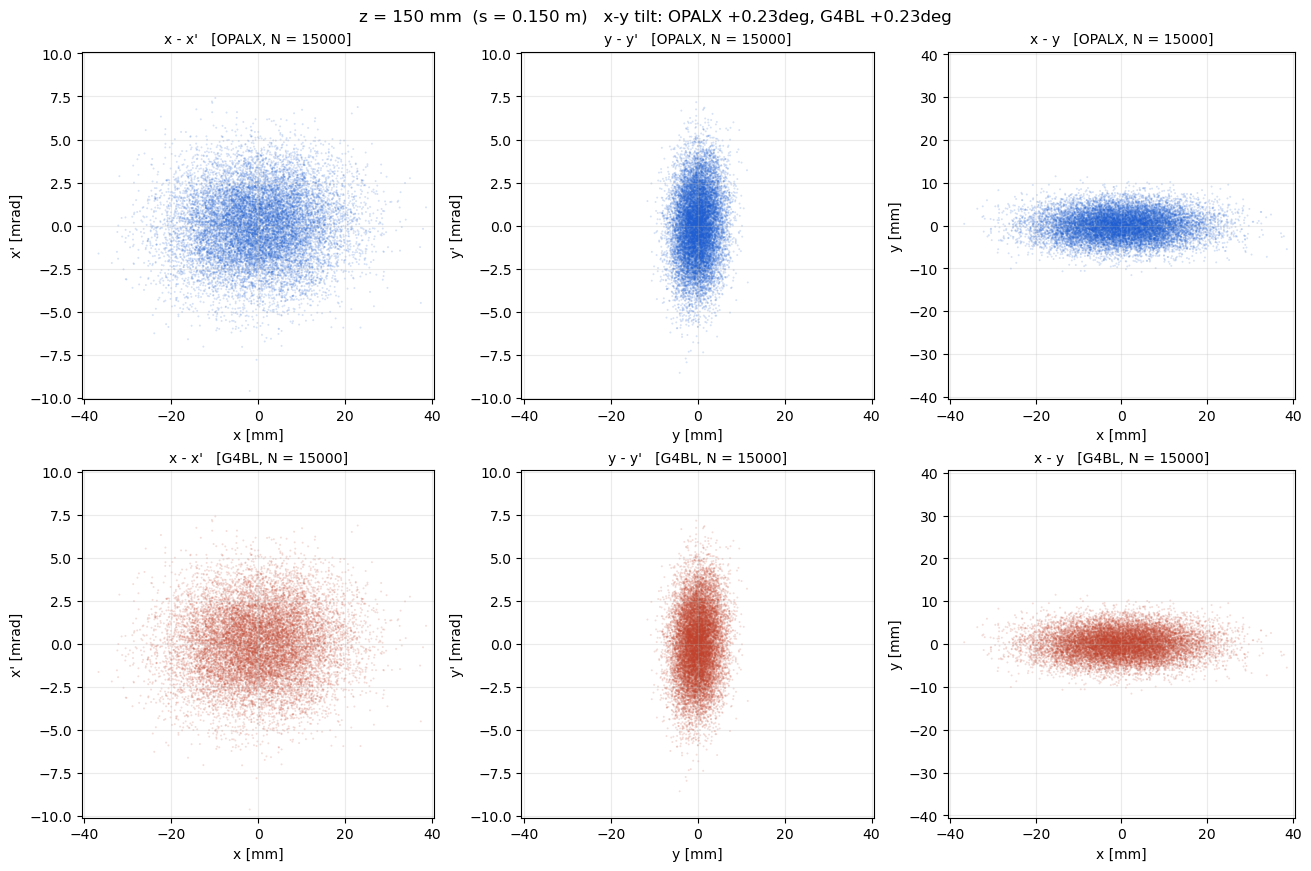

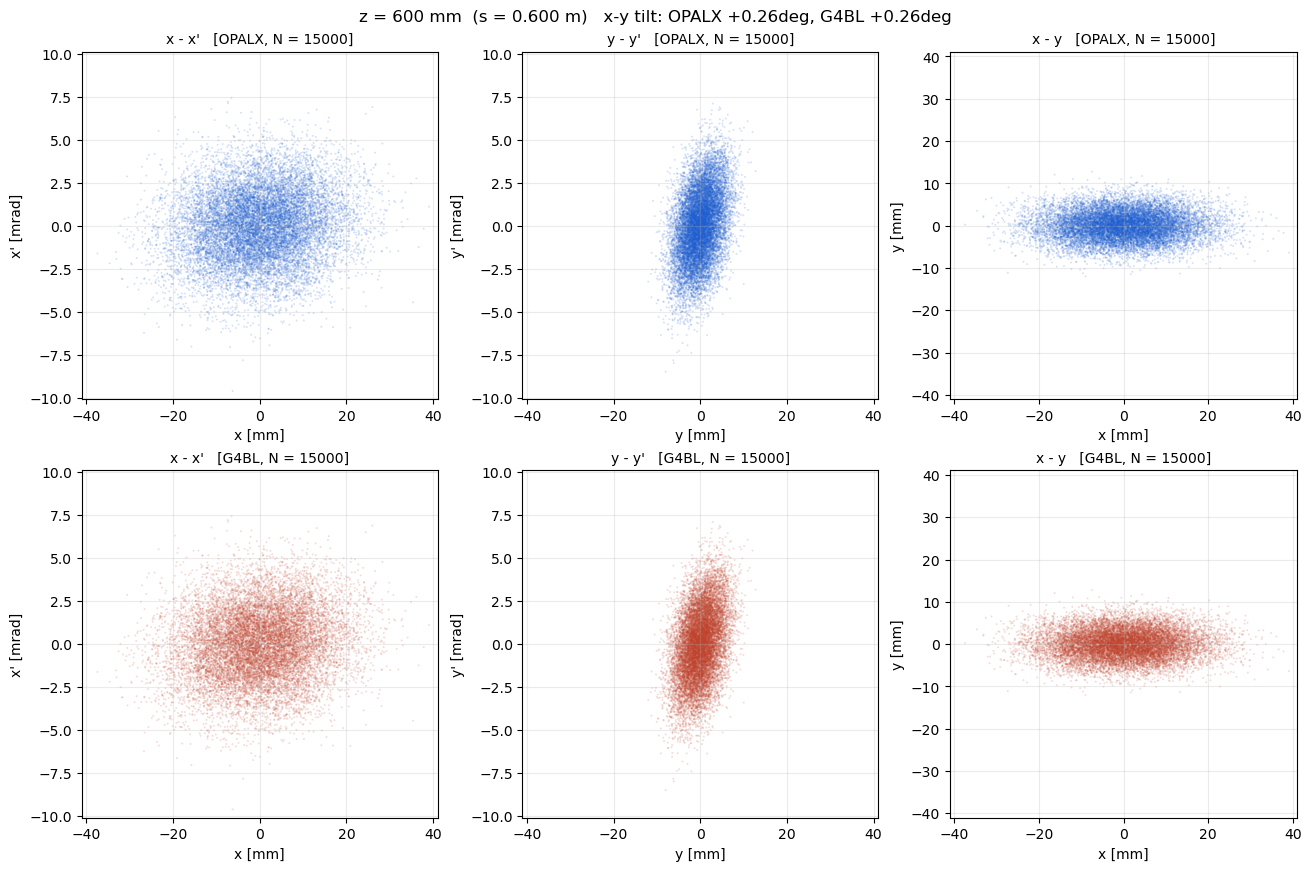

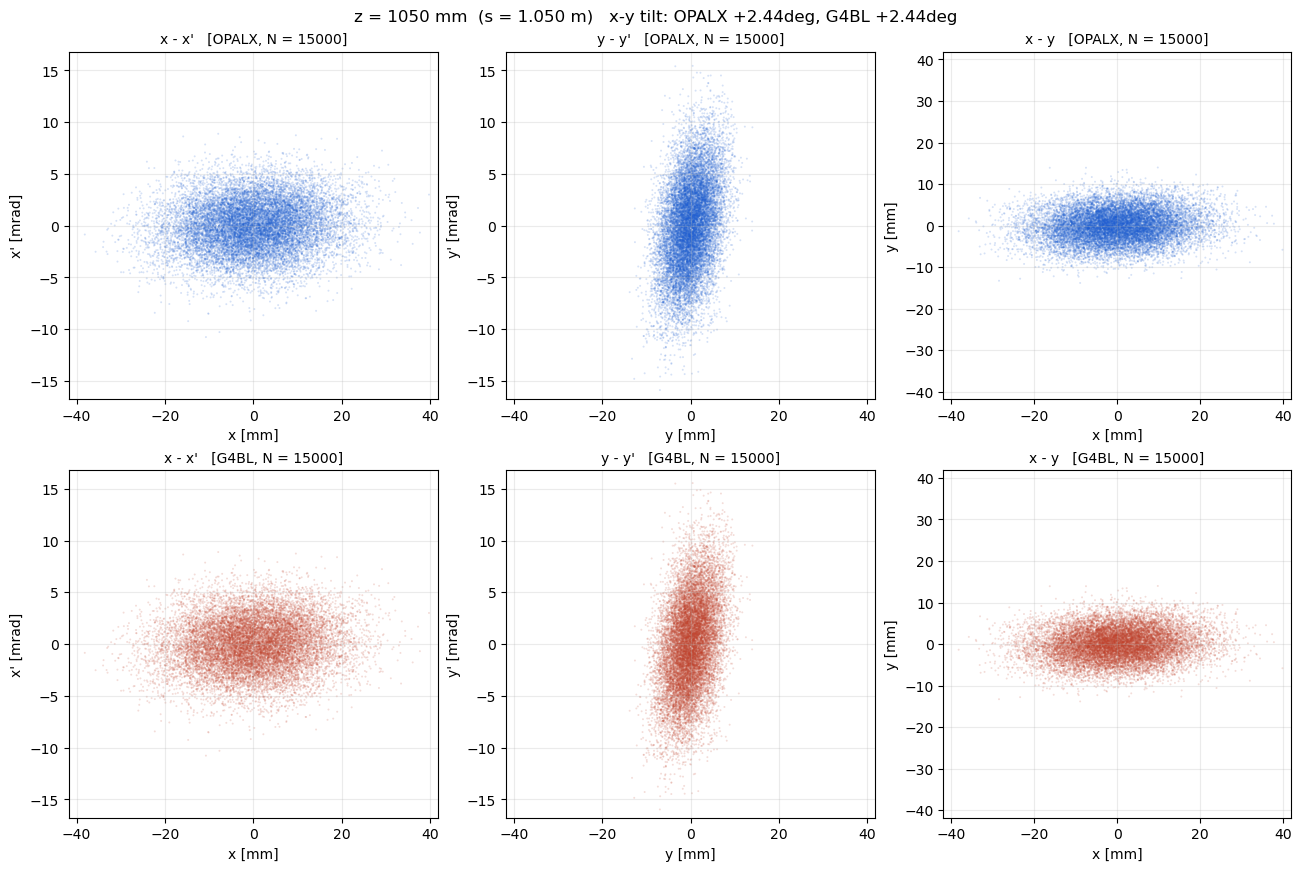

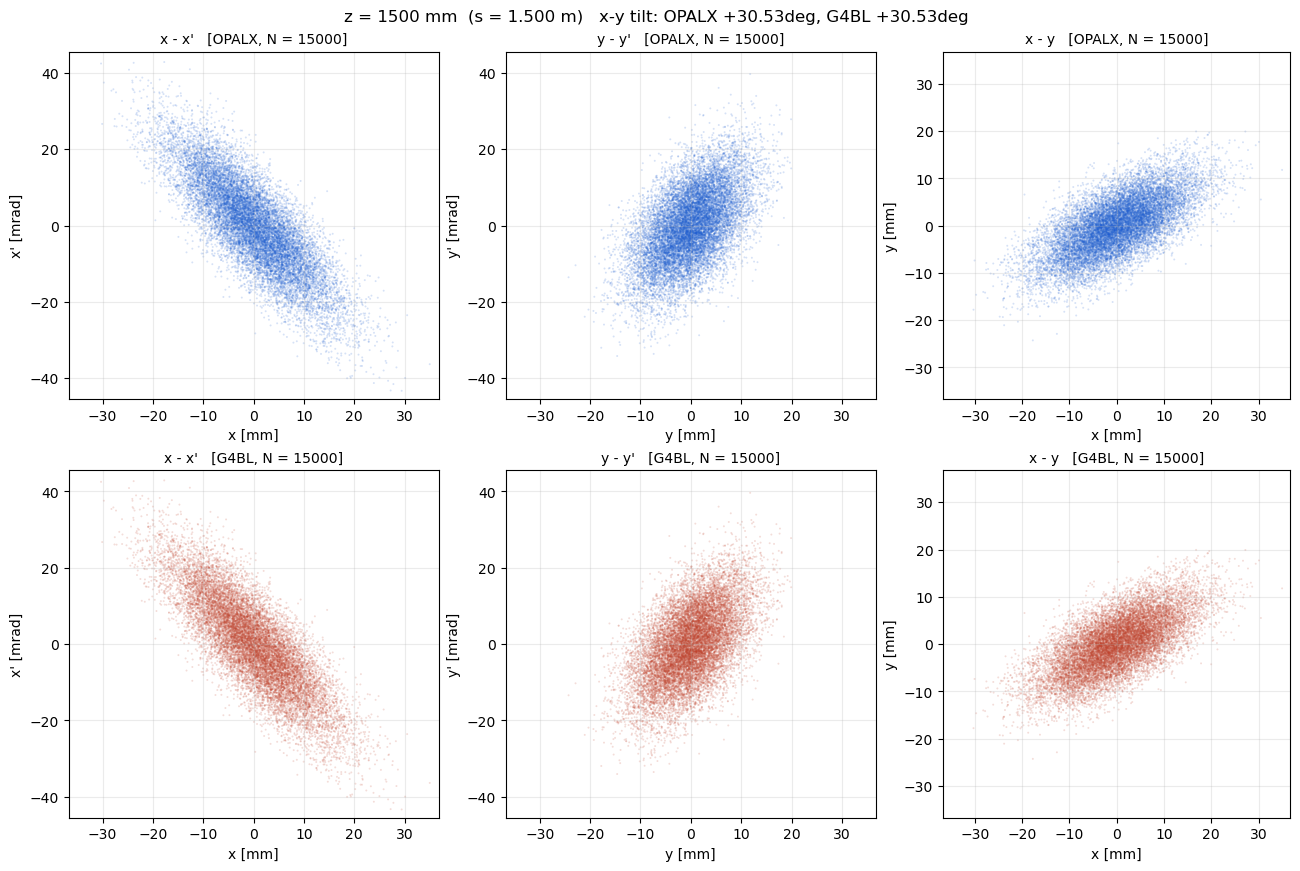

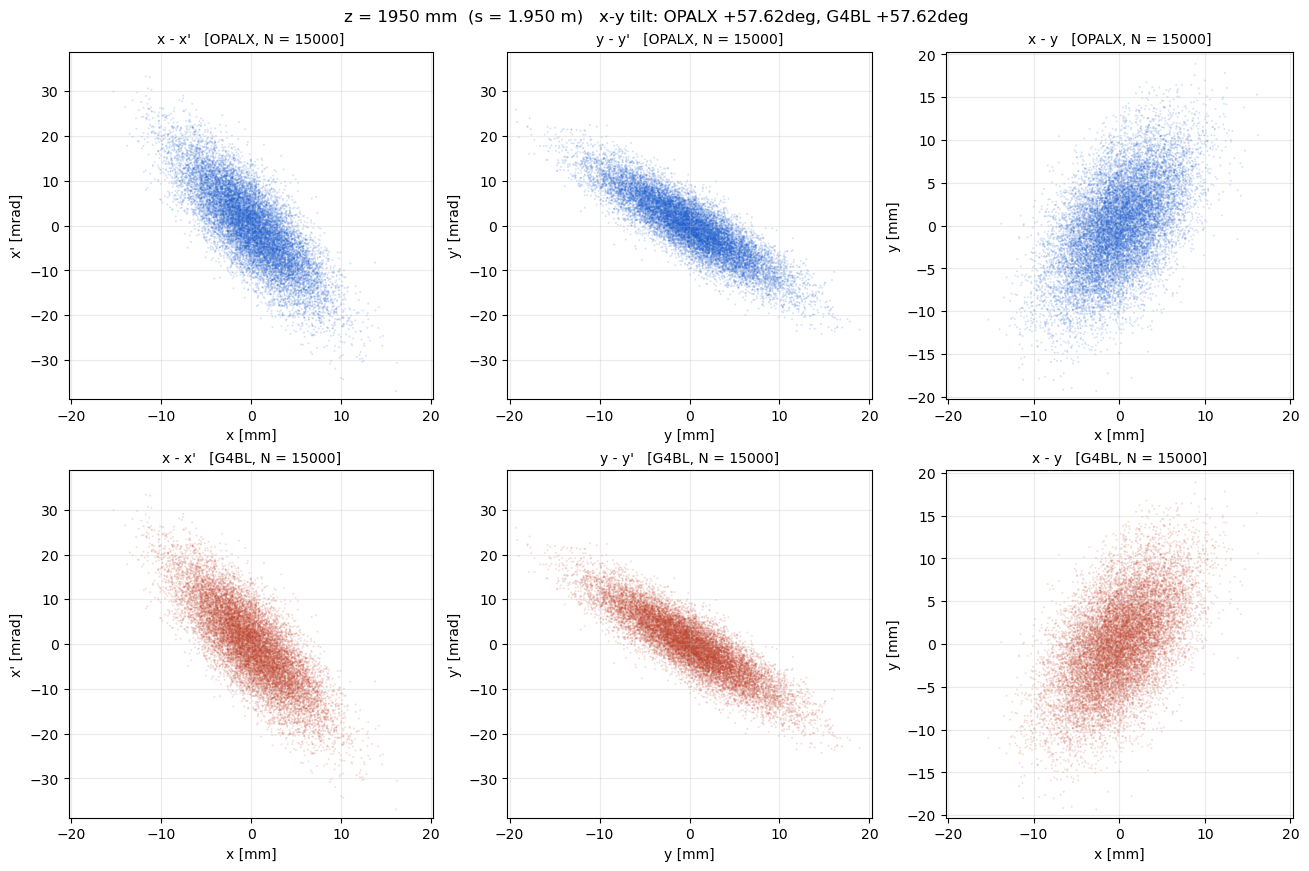

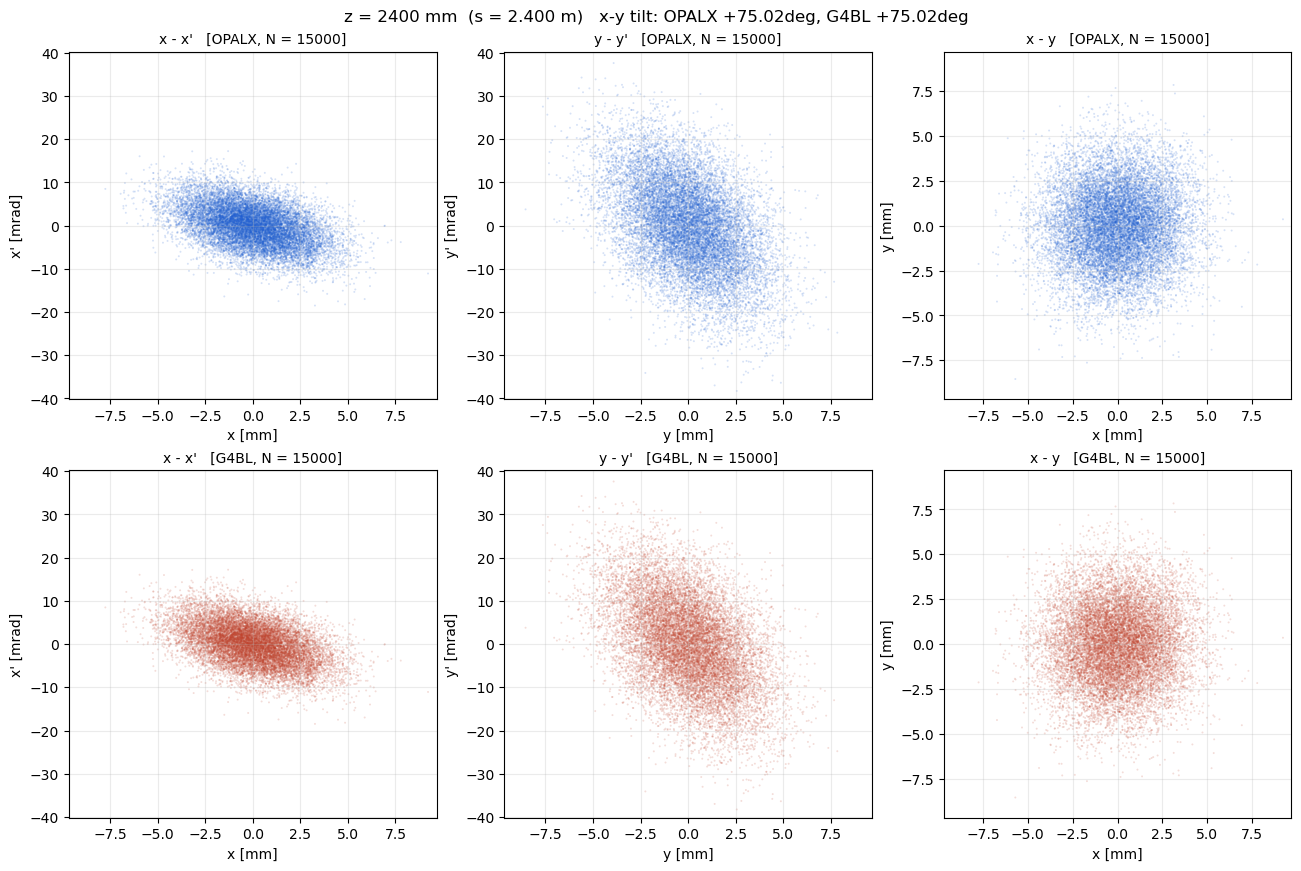

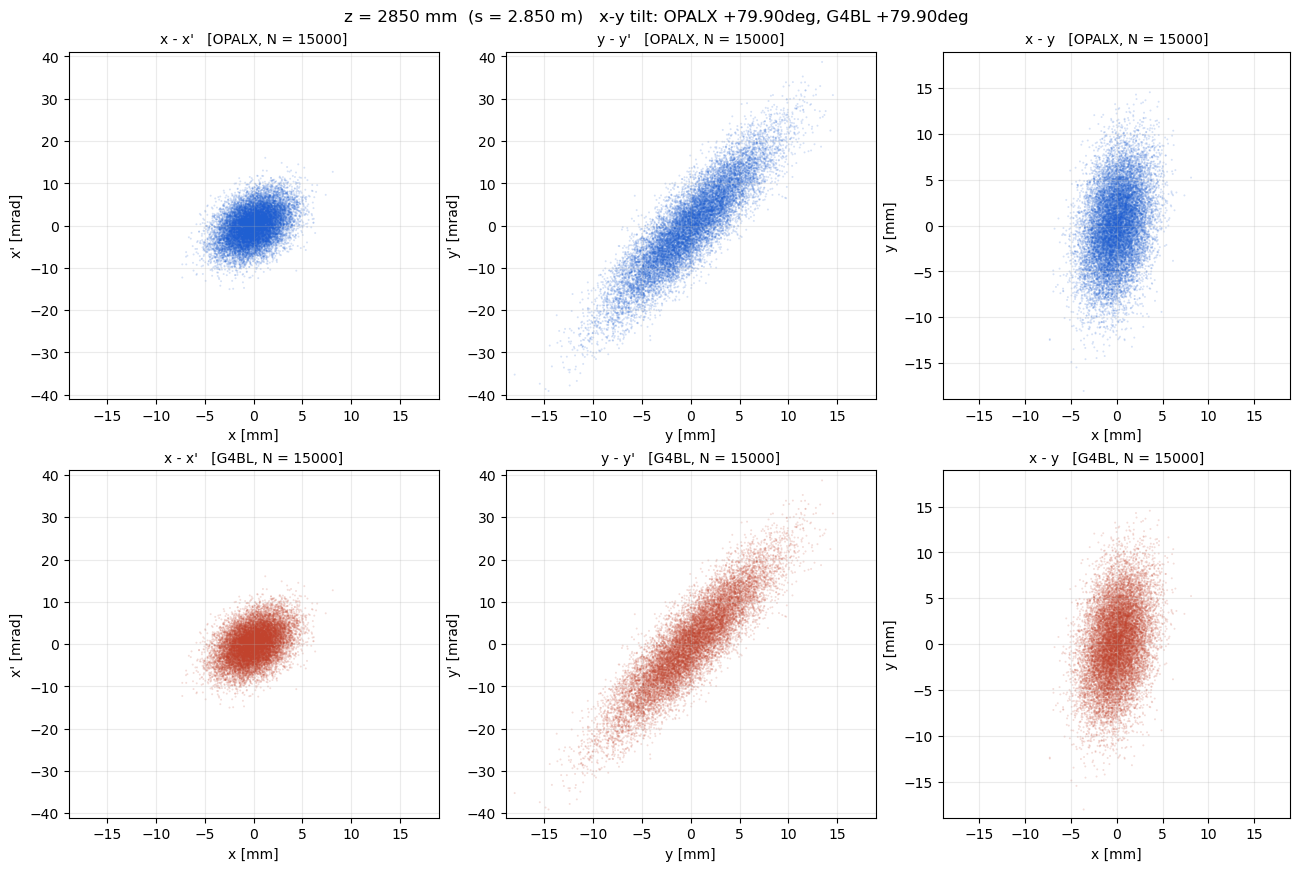

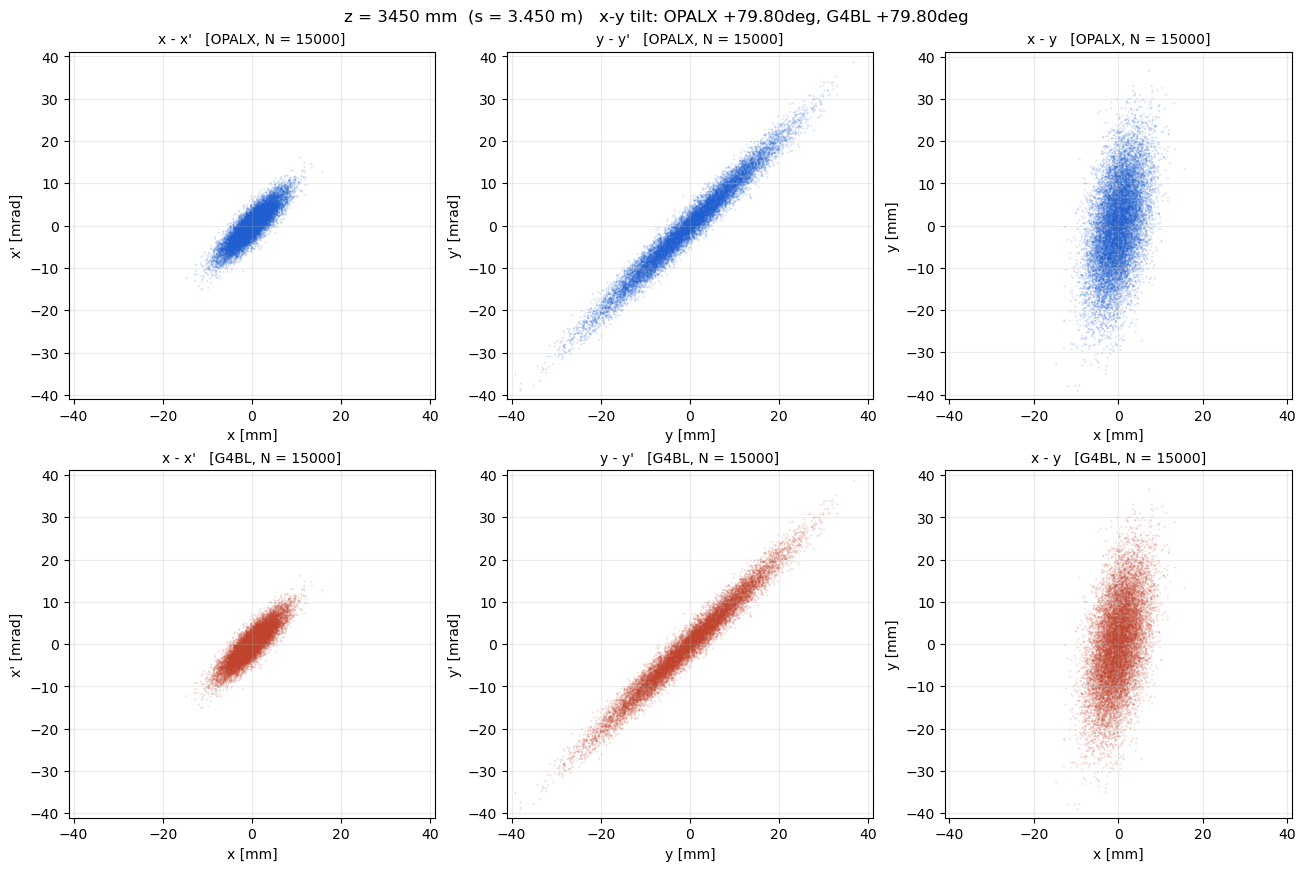

In [52]:
OPALX_BLUE = "#1f5fd1"
G4BL_RED   = "#c1432d"
ALPHA      = 0.18          # house style is 0.35 at ~5k points; 15k needs less


def plot_pair(z_mm, o, g, outdir=Path("monitor_plots"), pm=None, am=None):
    outdir.mkdir(exist_ok=True)

    # One range for every position axis, one for every angle axis, symmetric about
    # zero and taken over BOTH codes -- so all six panels share a scale.
    if pm is None:
        pm = 1.05 * max(np.abs(d[k]).max() for d in (o, g) for k in ("x", "y"))
    if am is None:
        am = 1.05 * max(np.abs(d[k]).max() for d in (o, g) for k in ("xp", "yp"))

    #        u    v     xlabel      ylabel        title     xlim  ylim
    panels = [("x", "xp", "x [mm]", "x' [mrad]", "x - x'", pm, am),
              ("y", "yp", "y [mm]", "y' [mrad]", "y - y'", pm, am),
              ("x", "y",  "x [mm]", "y [mm]",    "x - y",  pm, pm)]

    fig, ax = plt.subplots(2, 3, figsize=(13, 8.6), constrained_layout=True)
    for row, (d, colour, tag) in enumerate([(o, OPALX_BLUE, "OPALX"),
                                            (g, G4BL_RED, "G4BL")]):
        for col, (ku, kv, xl, yl, tt, ulim, vlim) in enumerate(panels):
            a = ax[row, col]
            a.scatter(d[ku], d[kv], s=2, alpha=ALPHA, edgecolors="none", color=colour)
            a.set_xlabel(xl); a.set_ylabel(yl)
            a.set_title(f"{tt}   [{tag}, N = {d['n']}]", fontsize=10)
            a.grid(True, alpha=0.25)
            a.set_xlim(-ulim, ulim); a.set_ylim(-vlim, vlim)
            if ku == "x" and kv == "y":
                # equal aspect, or the tilt is sheared by the panel shape
                a.set_aspect("equal", adjustable="box")

    tilt_o, tilt_g = ellipse_tilt_deg(o["x"], o["y"]), ellipse_tilt_deg(g["x"], g["y"])
    fig.suptitle(f"z = {z_mm} mm  (s = {z_mm/1e3:.3f} m)   "
                 f"x-y tilt: OPALX {tilt_o:+.2f}deg, G4BL {tilt_g:+.2f}deg", fontsize=12)
    fig.savefig(outdir / f"Z{z_mm}.png", dpi=110)
    return fig


for z, oo, gg in zip(PLANES_MM, O, G):
    plot_pair(z, oo, gg)
plt.show()


## Projections at the first and last plane

The same particles as above, binned instead of scattered. A scatter shows the shape of
the distribution; a histogram shows whether the two codes populate it the *same way* —
tails included, which is where a scatter is least readable.

One row per plane, one column per coordinate. Bin edges are shared between the codes
(and between the two rows) so the bars mean the same thing everywhere; position columns
share one range and angle columns another, as in the scatter panels. G4BL is dashed so
the two are told apart by more than colour where they overlap — which is nearly
everywhere.


 z [mm]  coord   mean OPALX    mean G4BL   rms OPALX    rms G4BL     d(rms)
----------------------------------------------------------------------------
    150      x     +0.00001     +0.00001     9.97774     9.97774  -4.62e-08
    150     xp     -0.00000     +0.00000     1.99676     1.99676  -2.00e-09
    150      y     -0.00001     -0.00001     3.02420     3.02420  -8.58e-09
    150     yp     -0.00000     -0.00000     1.99690     1.99690  +1.16e-07
   3450      x     -0.00000     -0.00000     3.55965     3.55966  -4.59e-06
   3450     xp     +0.00001     +0.00001     3.90515     3.90515  -2.15e-06
   3450      y     -0.00014     -0.00014    10.08921    10.08923  -1.95e-05
   3450     yp     -0.00007     -0.00007    10.37071    10.37072  -8.48e-06


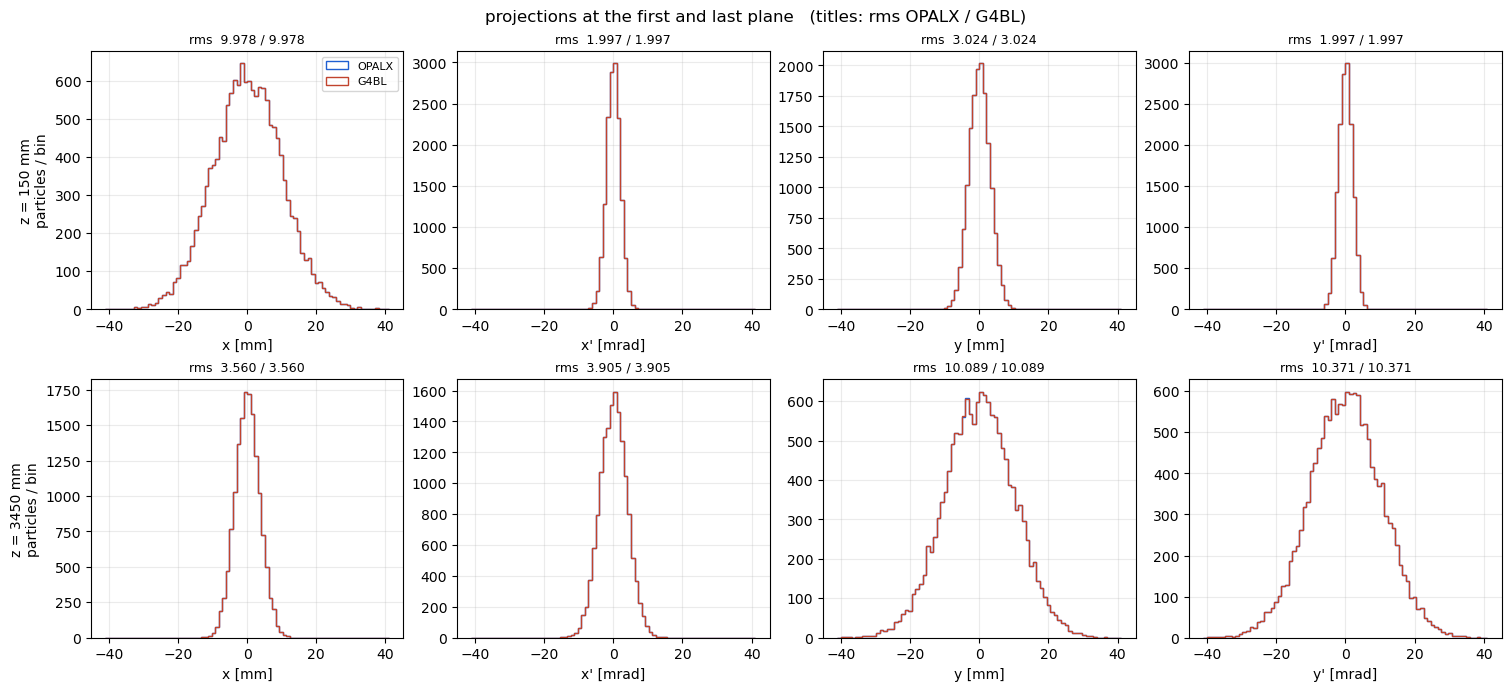

In [53]:
def projections(planes=(0, -1), nbins=80, outdir=Path("monitor_plots")):
    outdir.mkdir(exist_ok=True)
    idx  = [range(len(PLANES_MM))[i] for i in planes]
    cols = [("x", "x [mm]"), ("xp", "x' [mrad]"),
            ("y", "y [mm]"), ("yp", "y' [mrad]")]

    # shared ranges: one for positions, one for angles, over both codes AND both rows
    pm = 1.05 * max(np.abs(d[k]).max() for i in idx for d in (O[i], G[i])
                    for k in ("x", "y"))
    am = 1.05 * max(np.abs(d[k]).max() for i in idx for d in (O[i], G[i])
                    for k in ("xp", "yp"))
    edges = {"x": np.linspace(-pm, pm, nbins + 1), "y": np.linspace(-pm, pm, nbins + 1),
             "xp": np.linspace(-am, am, nbins + 1), "yp": np.linspace(-am, am, nbins + 1)}

    fig, ax = plt.subplots(len(idx), 4, figsize=(15, 3.4 * len(idx)),
                           constrained_layout=True)
    ax = np.atleast_2d(ax)
    rows = []
    for r, i in enumerate(idx):
        o, g = O[i], G[i]
        for c, (k, xl) in enumerate(cols):
            a = ax[r, c]
            a.hist(o[k], bins=edges[k], histtype="step", lw=1.8, color=OPALX_BLUE,
                   label="OPALX")
            a.hist(g[k], bins=edges[k], histtype="step", lw=1.5, ls="--", color=G4BL_RED,
                   label="G4BL")
            a.set_xlabel(xl); a.grid(alpha=0.25)
            if c == 0:
                a.set_ylabel(f"z = {PLANES_MM[i]} mm\nparticles / bin")
            if r == 0 and c == 0:
                a.legend(fontsize=8)
            a.set_title(f"rms  {np.std(o[k]):.3f} / {np.std(g[k]):.3f}", fontsize=9)
            rows.append((PLANES_MM[i], k, np.mean(o[k]), np.mean(g[k]),
                         np.std(o[k]), np.std(g[k])))
    fig.suptitle("projections at the first and last plane   "
                 "(titles: rms OPALX / G4BL)", fontsize=12)
    fig.savefig(outdir / "projections.png", dpi=110)

    print(f"{'z [mm]':>7} {'coord':>6} {'mean OPALX':>12} {'mean G4BL':>12} "
          f"{'rms OPALX':>11} {'rms G4BL':>11} {'d(rms)':>10}")
    print("-" * 76)
    for z, k, mo, mg, so, sg in rows:
        print(f"{z:>7} {k:>6} {mo:>+12.5f} {mg:>+12.5f} {so:>11.5f} {sg:>11.5f} "
              f"{so - sg:>+10.2e}")
    return fig


projections()
plt.show()


## Rotation and sizes along the line

The x–y ellipse tilt measured from each code, against the cumulative Larmor angle from
the field alone,

$$\theta_L(s) = \frac{1}{2B\rho}\int_0^s B_z\,ds'$$

which is an independent prediction — it uses only the field map, no tracking.


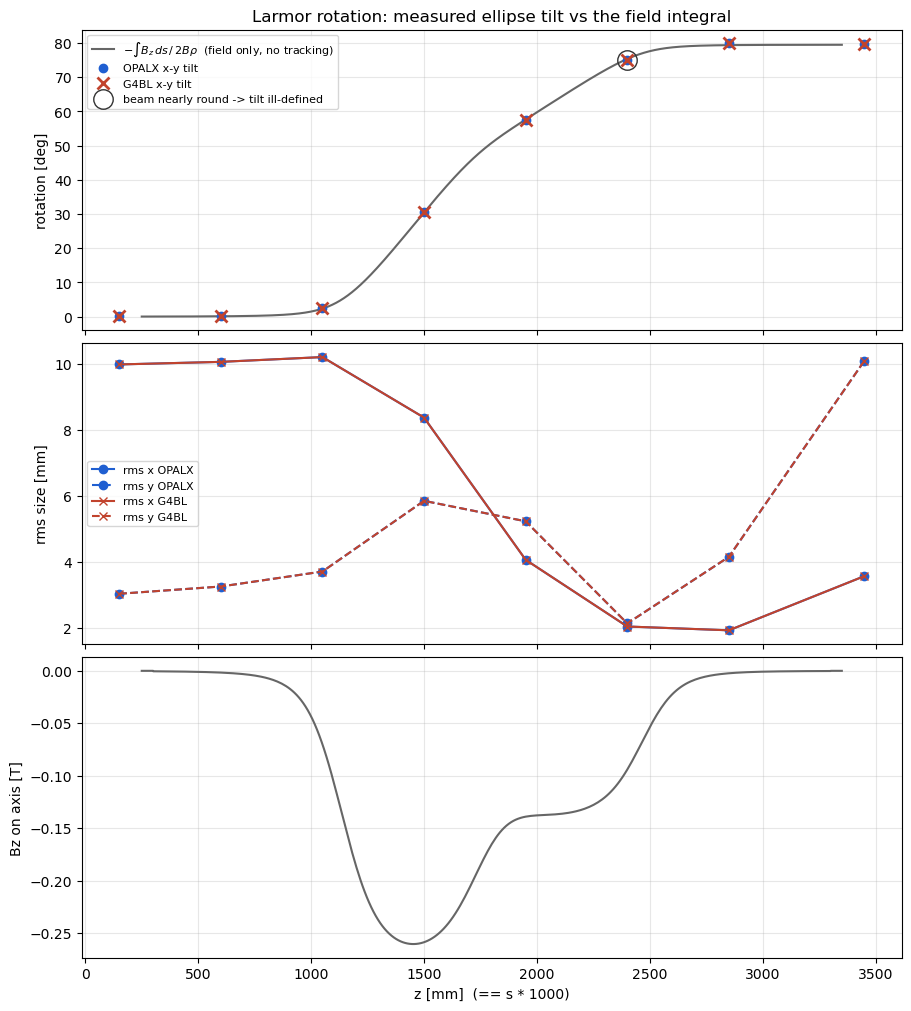

 z [mm]  OPALX tilt   G4BL tilt        O-G  predicted  aspect         rms x  O/G        rms y  O/G
----------------------------------------------------------------------------------------------------
    150      +0.226      +0.226   -1.0e-07     -0.000    3.30    9.978/9.978       3.024/3.024    
    600      +0.265      +0.265   -7.4e-07     +0.079    3.10   10.056/10.056      3.245/3.245    
   1050      +2.439      +2.439   -7.4e-05     +2.319    2.76   10.201/10.201      3.698/3.698    
   1500     +30.525     +30.525   +4.2e-05    +30.443    1.43    8.366/8.366       5.842/5.842    
   1950     +57.622     +57.621   +6.2e-05    +57.629    1.29    4.055/4.055       5.222/5.222    
   2400     +75.021     +75.021   +4.6e-04    +75.339    1.05    2.032/2.032       2.125/2.125      <- round, tilt ill-defined
   2850     +79.903     +79.903   -2.8e-05    +79.373    2.16    1.917/1.917       4.145/4.145    
   3450     +79.796     +79.796   -2.1e-05    +79.475    2.83    3.560/3.560   

In [54]:
d = np.loadtxt("g4bl_axis.txt", comments="#", ndmin=2)
z_ax, bz_ax = d[:, 2], d[:, 6]
theta_cum = np.concatenate([[0.0], np.cumsum(
    0.5 * (bz_ax[1:] + bz_ax[:-1]) * np.diff(z_ax * 1e-3))]) / (2 * BRHO)

# SIGN. With the block convention M_4x4 = [[cos*A, sin*A], [-sin*A, cos*A]], the
# lab-frame beam turns by -theta_L, not +theta_L: the (x,y) pair is acted on by
# R(-theta). So the ellipse tilt is compared against -theta_cum.
rot_pred = -np.degrees(theta_cum)

s_mm   = np.array(PLANES_MM, dtype=float)
tilt_o = np.array([ellipse_tilt_deg(o["x"], o["y"]) for o in O])
tilt_g = np.array([ellipse_tilt_deg(g["x"], g["y"]) for g in G])
pred_at = np.interp(s_mm, z_ax, rot_pred)
aspect  = np.array([max(np.std(o["x"]), np.std(o["y"])) /
                    min(np.std(o["x"]), np.std(o["y"])) for o in O])

fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
ax[0].plot(z_ax, rot_pred, "-", color="0.4",
           label=r"$-\int B_z\,ds\,/\,2B\rho$  (field only, no tracking)")
ax[0].plot(s_mm, tilt_o, "o", color=OPALX_BLUE, label="OPALX x-y tilt")
ax[0].plot(s_mm, tilt_g, "x", ms=9, mew=2, color=G4BL_RED, label="G4BL x-y tilt")
round_ = aspect < 1.15
if round_.any():
    ax[0].plot(s_mm[round_], tilt_o[round_], "o", ms=14, mfc="none",
               mec="0.2", label="beam nearly round -> tilt ill-defined")
ax[0].set_ylabel("rotation [deg]"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[0].set_title("Larmor rotation: measured ellipse tilt vs the field integral")

for d_, colour, tag, mk in [(O, OPALX_BLUE, "OPALX", "o"), (G, G4BL_RED, "G4BL", "x")]:
    ax[1].plot(s_mm, [np.std(v["x"]) for v in d_], mk + "-", color=colour, label=f"rms x {tag}")
    ax[1].plot(s_mm, [np.std(v["y"]) for v in d_], mk + "--", color=colour, label=f"rms y {tag}")
ax[1].set_ylabel("rms size [mm]"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].plot(z_ax, bz_ax, "-", color="0.4")
ax[2].set_ylabel("Bz on axis [T]"); ax[2].set_xlabel("z [mm]  (== s * 1000)")
ax[2].grid(alpha=.3)
plt.show()

print(f"{'z [mm]':>7} {'OPALX tilt':>11} {'G4BL tilt':>11} {'O-G':>10} "
      f"{'predicted':>10} {'aspect':>7}  {'rms x  O/G':>17} {'rms y  O/G':>17}")
print("-" * 100)
for i, z in enumerate(PLANES_MM):
    flag = "  <- round, tilt ill-defined" if aspect[i] < 1.15 else ""
    print(f"{z:>7} {tilt_o[i]:>+11.3f} {tilt_g[i]:>+11.3f} {tilt_o[i]-tilt_g[i]:>+10.1e} "
          f"{pred_at[i]:>+10.3f} {aspect[i]:>7.2f}  "
          f"{np.std(O[i]['x']):>7.3f}/{np.std(G[i]['x']):<9.3f} "
          f"{np.std(O[i]['y']):>7.3f}/{np.std(G[i]['y']):<9.3f}{flag}")
print("\nThe tilt is the orientation of the x-y covariance ellipse, defined modulo 180 deg.")
print("Where the beam is nearly round (aspect ~ 1) the orientation is degenerate and the")
print("measured tilt carries no information -- the two codes still agree with each other")
print("there, they just agree on a meaningless number.")
